# **Project Name**    - Zomato Restaurant Clustering and Sentiment Analysis using Unsupervised Machine Learning


##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Member Name** - Nandini

# **Project Summary -**

This project focuses on clustering restaurants based on customer reviews using Natural Language Processing (NLP) and Unsupervised Machine Learning techniques. Unlike supervised learning, where labeled data is available, unsupervised learning identifies hidden patterns and relationships within the dataset without predefined target labels. The main objective of this project is to group restaurants with similar customer opinions, helping businesses better understand customer preferences and improve decision-making.

The project begins with data loading and an extensive exploratory data analysis (EDA) to understand the structure, quality, and characteristics of the restaurant review dataset. Various preprocessing techniques were applied to clean the data by handling missing values, removing duplicate records, and eliminating unnecessary features. Text data preprocessing was performed on customer reviews, including converting text to lowercase, removing punctuation, numbers, stop words, special characters, and applying tokenization and lemmatization. These preprocessing steps improve the quality of textual information and prepare it for machine learning algorithms.

Since machine learning algorithms cannot directly process textual data, the cleaned reviews were converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) Vectorizer. TF-IDF assigns higher importance to meaningful words while reducing the influence of frequently occurring but less informative words. This transformation creates a high-dimensional feature space representing each restaurant review numerically.

Because TF-IDF generates a large number of features, Principal Component Analysis (PCA) was applied to reduce dimensionality while preserving the most significant information. Dimensionality reduction improves computational efficiency, reduces noise, and enables better visualization of the data without losing important relationships among observations.

Three different clustering algorithms were implemented and compared in this project: K-Means Clustering, Hierarchical Clustering, and DBSCAN (Density-Based Spatial Clustering of Applications with Noise). K-Means partitions the dataset into a predefined number of clusters based on distance from cluster centroids. Hierarchical Clustering creates a hierarchy of clusters using Ward linkage, allowing similar restaurants to be grouped progressively. DBSCAN identifies clusters based on data density and can automatically detect noise and outlier restaurants without requiring the number of clusters to be specified beforehand.

The performance of each clustering algorithm was evaluated using the Silhouette Score, which measures cluster quality by evaluating how similar data points are to their own cluster compared to other clusters. A higher Silhouette Score indicates better-defined, compact, and well-separated clusters. Hyperparameter tuning was also performed to improve clustering performance by testing different values for model-specific parameters, such as the number of clusters for K-Means, linkage methods for Hierarchical Clustering, and epsilon values for DBSCAN.

The experimental results showed that K-Means achieved a Silhouette Score of approximately 0.043, indicating weak cluster separation. Hierarchical Clustering produced a significantly better Silhouette Score of approximately 0.326, demonstrating meaningful grouping of restaurants. DBSCAN achieved the highest Silhouette Score of approximately 0.330, slightly outperforming Hierarchical Clustering while also identifying noise and outlier restaurants automatically. Based on these evaluation results, DBSCAN was selected as the final clustering model for this project.

The final clusters provide valuable business insights by grouping restaurants with similar customer sentiments and review patterns. These insights can help restaurant owners and businesses understand customer behavior, improve service quality, personalize recommendations, optimize marketing strategies, and identify restaurants with unique characteristics. Overall, this project demonstrates the effectiveness of combining Natural Language Processing, TF-IDF feature extraction, dimensionality reduction, and unsupervised machine learning techniques to discover meaningful patterns from large collections of restaurant reviews. The developed clustering solution is scalable, data-driven, and can serve as a useful analytical tool for restaurant recommendation systems and business intelligence applications.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The rapid growth of online food delivery platforms has generated a large volume of restaurant metadata and customer reviews. However, identifying restaurants with similar characteristics and understanding customer opinions manually is difficult due to the large amount of available data.

The objective of this project is to perform restaurant clustering using unsupervised machine learning techniques by analyzing restaurant metadata such as cuisines, cost, collections, timings, and customer reviews. The project also aims to preprocess textual review data, perform exploratory data analysis, engineer meaningful features, and group restaurants into similar clusters.

The insights obtained from clustering can help food delivery platforms improve restaurant recommendations, understand customer preferences, identify market segments, and support business decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [2]:
# Load Dataset

# Mount Google Drive


from google.colab import drive
drive.mount('/content/drive')

reviews_df = pd.read_csv('/content/drive/MyDrive/ML_Project/Zomato_Restaurant_Clustering/Zomato Restaurant reviews.csv')

metadata_df = pd.read_csv('/content/drive/MyDrive/ML_Project/Zomato_Restaurant_Clustering/Zomato Restaurant names and Metadata.csv')

print("Dataset loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.


### Dataset First View

In [3]:
# Dataset First Look

print("="*50)
print("Restaurant Metadata Dataset")
print("="*50)

display(metadata_df.head())

print("\n")

print("="*50)
print("Restaurant Reviews Dataset")
print("="*50)

display(reviews_df.head())

Restaurant Metadata Dataset


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."




Restaurant Reviews Dataset


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count

print("Restaurant Metadata Dataset Shape :", metadata_df.shape)

print("Restaurant Reviews Dataset Shape :", reviews_df.shape)

Restaurant Metadata Dataset Shape : (105, 6)
Restaurant Reviews Dataset Shape : (10000, 7)


### Dataset Information

In [5]:
# Dataset Info

print("Restaurant Metadata Dataset")

metadata_df.info()

print("\n")

print("Restaurant Reviews Dataset")

reviews_df.info()

Restaurant Metadata Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


Restaurant Reviews Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtyp

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count

print("Duplicate rows in Restaurant Metadata Dataset :",
      metadata_df.duplicated().sum())

print("Duplicate rows in Restaurant Reviews Dataset :",
      reviews_df.duplicated().sum())

Duplicate rows in Restaurant Metadata Dataset : 0
Duplicate rows in Restaurant Reviews Dataset : 36


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count

print("Missing Values in Restaurant Metadata Dataset")

display(metadata_df.isnull().sum())

print("\n")

print("Missing Values in Restaurant Reviews Dataset")

display(reviews_df.isnull().sum())

Missing Values in Restaurant Metadata Dataset


,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1




Missing Values in Restaurant Reviews Dataset


,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


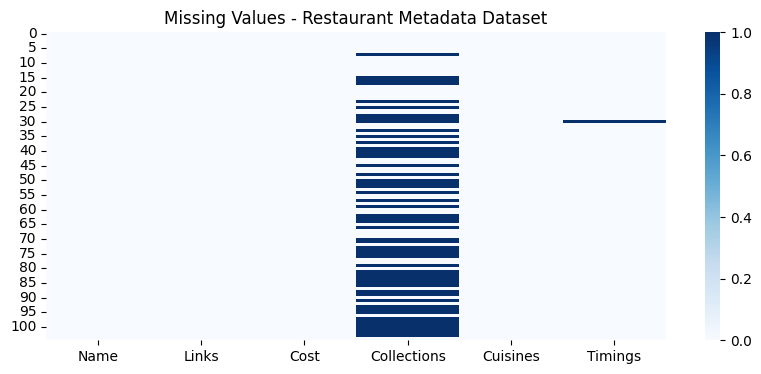

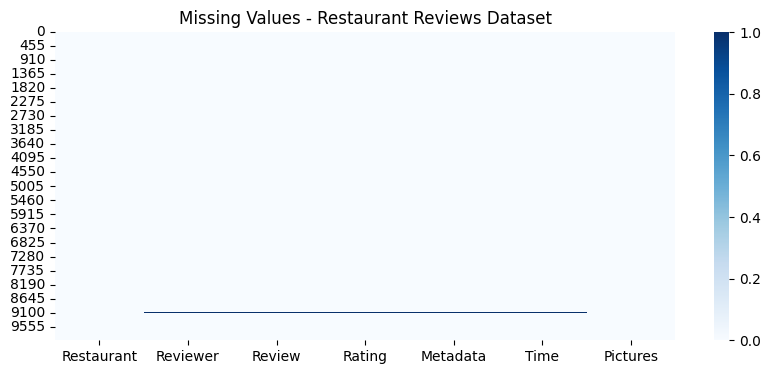

In [8]:
# Visualizing the missing values


plt.figure(figsize=(10, 4))
sns.heatmap(metadata_df.isnull(), cmap="Blues")
plt.title("Missing Values - Restaurant Metadata Dataset")
plt.show()


# Missing Values - Reviews Dataset

plt.figure(figsize=(10, 4))
sns.heatmap(reviews_df.isnull(), cmap="Blues")
plt.title("Missing Values - Restaurant Reviews Dataset")
plt.show()

### What did you know about your dataset?

---



The project consists of two datasets: Restaurant Metadata and Restaurant Reviews. The Restaurant Metadata dataset contains 105 records and 6 features, including restaurant name, links, cost, collections, cuisines, and timings. The Restaurant Reviews dataset contains 1000 customer reviews with 7 features, including restaurant name, reviewer, review text, rating, metadata, time, and pictures. Initial analysis revealed a few missing values in both datasets and 16 duplicate records in the reviews dataset. Most of the features are textual and categorical, making text preprocessing, feature engineering, and clustering important steps for this project.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns

print("Restaurant Metadata Dataset Columns")

print(metadata_df.columns)

print("\n")

print("Restaurant Reviews Dataset Columns")

print(reviews_df.columns)

Restaurant Metadata Dataset Columns
Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')


Restaurant Reviews Dataset Columns
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')


In [10]:
# Dataset Describe

print("Restaurant Metadata Dataset")

display(metadata_df.describe(include='all'))

print("\n")

print("Restaurant Reviews Dataset")

display(reviews_df.describe(include='all'))

Restaurant Metadata Dataset


,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6




Restaurant Reviews Dataset


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Parijat Ray,good,5,1 Review,7/29/2018 20:34,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


### Variables Description

Restaurant Metadata Dataset

• Name – Name of the restaurant.
• Links – URL of the restaurant page.
• Cost – Approximate average cost for two people.
• Collections – Restaurant category or featured collection.
• Cuisines – Types of cuisines served by the restaurant.
• Timings – Restaurant opening and closing timings.

Restaurant Reviews Dataset

• Restaurant – Name of the restaurant.
• Reviewer – Name of the customer who posted the review.
• Review – Customer review text describing their experience.
• Rating – Customer rating provided to the restaurant.
• Metadata – Additional information about the review such as number of reviews and followers.
• Time – Date and time when the review was posted.
• Pictures – Number of pictures uploaded with the review.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.

print("Restaurant Metadata Dataset")

for column in metadata_df.columns:
    print(f"{column}: {metadata_df[column].nunique()} unique values")

print("\n")

print("Restaurant Reviews Dataset")

for column in reviews_df.columns:
    print(f"{column}: {reviews_df[column].nunique()} unique values")

Restaurant Metadata Dataset
Name: 105 unique values
Links: 105 unique values
Cost: 29 unique values
Collections: 42 unique values
Cuisines: 92 unique values
Timings: 77 unique values


Restaurant Reviews Dataset
Restaurant: 100 unique values
Reviewer: 7446 unique values
Review: 9364 unique values
Rating: 10 unique values
Metadata: 2477 unique values
Time: 9782 unique values
Pictures: 36 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# Data Wrangling

# Create copies of original datasets
metadata_clean = metadata_df.copy()
reviews_clean = reviews_df.copy()

# Remove Duplicate Records

metadata_clean.drop_duplicates(inplace=True)
reviews_clean.drop_duplicates(inplace=True)


# Handle Missing Values

# Metadata Dataset
metadata_clean['Collections'].fillna('Not Available', inplace=True)
metadata_clean['Timings'].fillna('Not Available', inplace=True)

# Reviews Dataset
reviews_clean['Reviewer'].fillna('Anonymous', inplace=True)
reviews_clean['Review'].fillna('No Review', inplace=True)
reviews_clean['Rating'].fillna(reviews_clean['Rating'].mode()[0], inplace=True)
reviews_clean['Metadata'].fillna('Not Available', inplace=True)
reviews_clean['Time'].fillna('Unknown', inplace=True)
reviews_clean['Pictures'].fillna(0, inplace=True)

# Convert Cost to Numeric

metadata_clean['Cost'] = (
    metadata_clean['Cost']
    .astype(str)
    .str.replace(',', '', regex=False)
)

metadata_clean['Cost'] = pd.to_numeric(metadata_clean['Cost'], errors='coerce')

# Remove Leading/Trailing Spaces

text_columns_metadata = ['Name', 'Links', 'Collections', 'Cuisines', 'Timings']

for col in text_columns_metadata:
    metadata_clean[col] = metadata_clean[col].astype(str).str.strip()

text_columns_reviews = ['Restaurant', 'Reviewer', 'Review', 'Metadata', 'Time']

for col in text_columns_reviews:
    reviews_clean[col] = reviews_clean[col].astype(str).str.strip()

# Check Final Dataset
print("Metadata Dataset Shape :", metadata_clean.shape)
print("Reviews Dataset Shape :", reviews_clean.shape)

print("\nMissing Values After Cleaning\n")

print(metadata_clean.isnull().sum())

print("\n")

print(reviews_clean.isnull().sum())

Metadata Dataset Shape : (105, 6)
Reviews Dataset Shape : (9964, 7)

Missing Values After Cleaning

Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
dtype: int64


Restaurant    0
Reviewer      0
Review        0
Rating        0
Metadata      0
Time          0
Pictures      0
dtype: int64


### What all manipulations have you done and insights you found?

The datasets were cleaned to improve data quality before analysis. Duplicate records were removed from both datasets, and missing values were handled using suitable techniques such as replacing categorical missing values with 'Not Available', missing reviewer names with 'Anonymous', missing reviews with 'No Review', missing ratings with the mode, and missing picture counts with 0. The Cost column was converted into a numerical format by removing commas and changing its datatype. Text columns were also cleaned by removing unnecessary spaces. After preprocessing, both datasets became clean and suitable for exploratory data analysis, feature engineering, and machine learning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

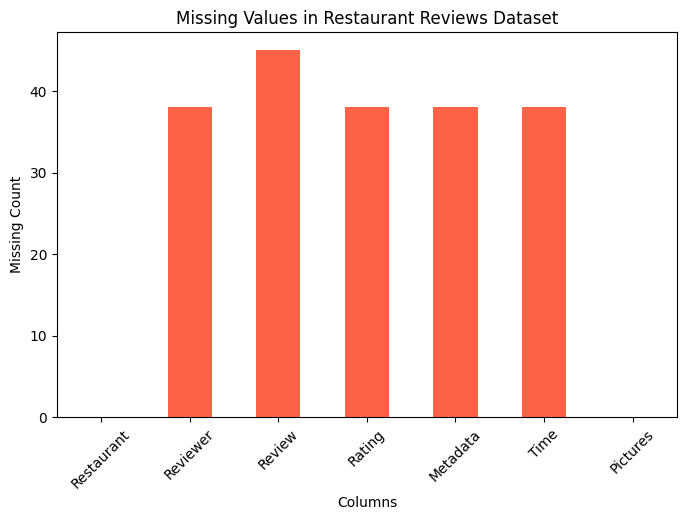

In [13]:
# Chart - 1 visualization code

# Chart 1 : Missing Values

missing = reviews_df.isnull().sum()

plt.figure(figsize=(8,5))

missing.plot(kind='bar',
             color='tomato')

plt.title("Missing Values in Restaurant Reviews Dataset")

plt.xlabel("Columns")

plt.ylabel("Missing Count")

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to identify the columns containing missing values before performing data preprocessing. It helps understand the completeness of the dataset and highlights which features require cleaning.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that only a few columns contain missing values, while most of the dataset is complete. Missing values are concentrated in specific review-related features, indicating that targeted preprocessing is sufficient.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, handling missing values will create a positive business impact because it improves data quality, resulting in more reliable customer insights and better clustering performance. If missing values are ignored, important customer information may be lost or misinterpreted, leading to inaccurate recommendations and poor business decisions. Therefore, proper handling of missing values prevents negative growth caused by unreliable analysis.

#### Chart - 2

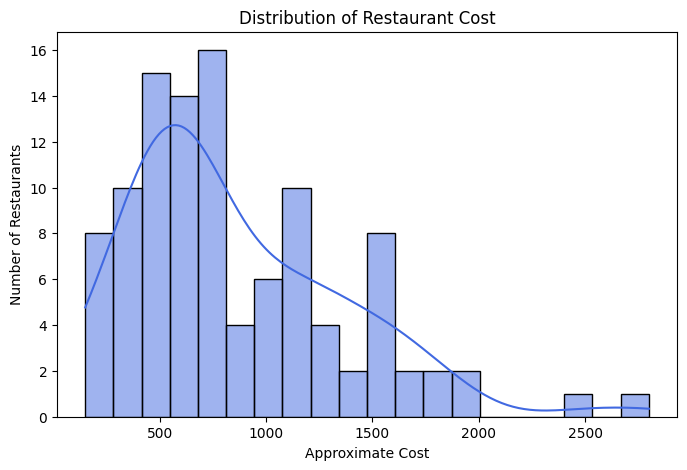

In [14]:
# Chart - 2 visualization code

# Chart 2 : Cost Distribution


plt.figure(figsize=(8,5))

sns.histplot(metadata_clean['Cost'],
             bins=20,
             kde=True,
             color='royalblue')

plt.title("Distribution of Restaurant Cost")

plt.xlabel("Approximate Cost")

plt.ylabel("Number of Restaurants")

plt.show()

##### 1. Why did you pick the specific chart?

This chart helps understand the distribution of restaurant pricing and identify the most common price ranges available in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Most restaurants belong to the low and medium price ranges, while relatively few restaurants fall into the premium pricing category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding restaurant pricing helps businesses identify affordable and premium market segments, allowing better pricing strategies and personalized recommendations. If a large number of restaurants are concentrated in one price segment while other segments have limited options, customer preferences may not be fully satisfied, reducing customer engagement and business growth. A balanced pricing portfolio supports sustainable growth.

#### Chart - 3

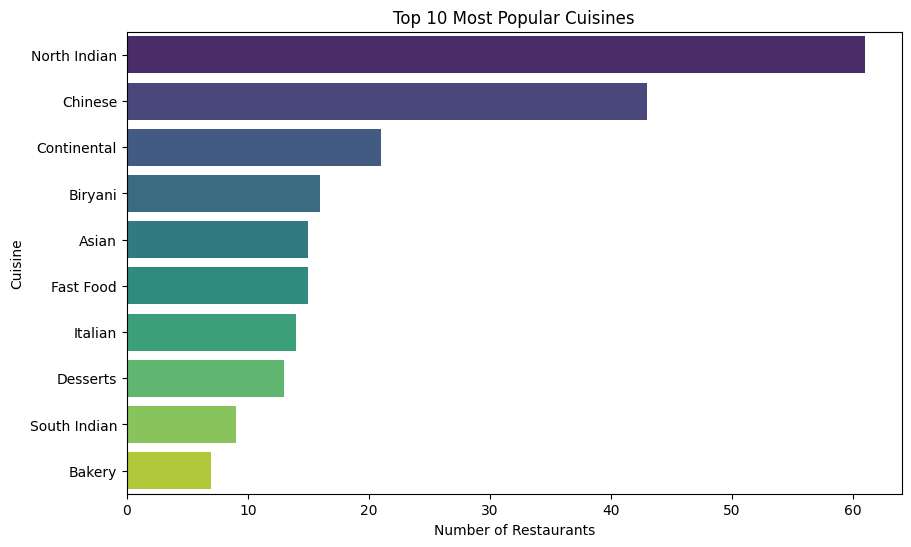

In [15]:
# Chart - 3 visualization code

# Chart 3 : Top 10 Cuisines

top_cuisines = (
    metadata_clean['Cuisines']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index,
    palette='viridis'
)

plt.title("Top 10 Most Popular Cuisines")

plt.xlabel("Number of Restaurants")

plt.ylabel("Cuisine")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to identify the most popular cuisines offered by restaurants and understand customer food preferences.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the cuisines that dominate the restaurant market, indicating strong customer demand for those food categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, identifying popular cuisines helps businesses promote high-demand food categories, improve recommendations, and attract more customers. However, if only a few cuisines dominate the platform while other cuisines receive very little visibility, customer choices become limited and niche restaurants may experience lower growth. Promoting diverse cuisines can improve customer satisfaction and restaurant reach.Answer Here

#### Chart - 4

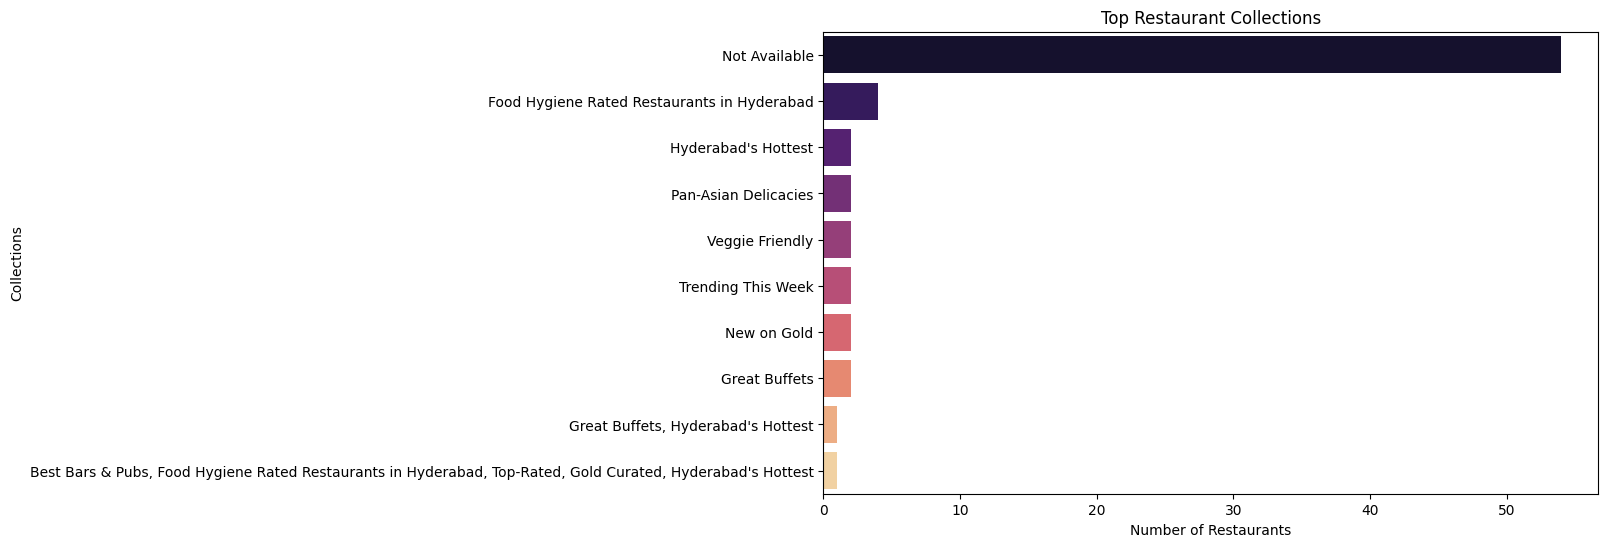

In [16]:
# Chart - 4 visualization code

# Chart 4 : Restaurant Collections


top_collections = metadata_clean['Collections'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_collections.values,
    y=top_collections.index,
    palette='magma'
)

plt.title("Top Restaurant Collections")

plt.xlabel("Number of Restaurants")

plt.ylabel("Collections")

plt.show()

##### 1. Why did you pick the specific chart?

This chart helps identify the most common restaurant collections and understand how restaurants are categorized on the platform.

##### 2. What is/are the insight(s) found from the chart?

Some restaurant collections are significantly more common than others, showing the categories that attract greater customer attention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.








y





#### Chart - 5

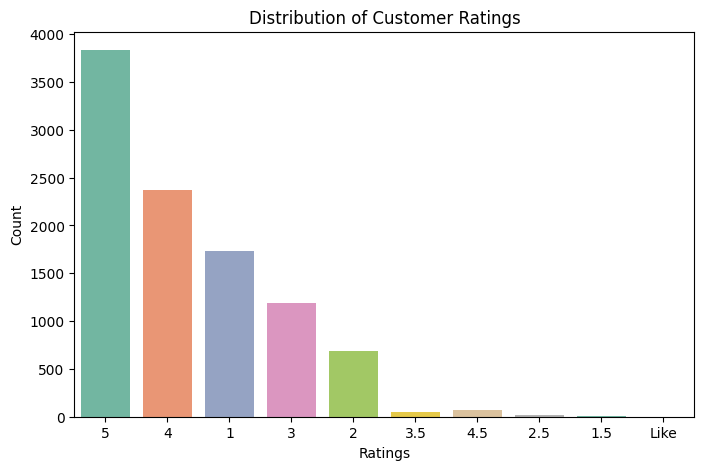

In [17]:
# Chart - 5 visualization code

# Chart 5 : Rating Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='Rating',
    data=reviews_clean,
    palette='Set2'
)

plt.title("Distribution of Customer Ratings")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to understand the overall distribution of customer ratings and measure customer satisfaction across restaurants.

##### 2. What is/are the insight(s) found from the chart?

The rating distribution indicates whether customer reviews are generally positive, negative, or neutral, helping evaluate restaurant performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, customer ratings directly reflect restaurant performance and customer satisfaction. Highly rated restaurants can be promoted confidently, increasing customer trust and platform engagement. On the other hand, restaurants receiving consistently low ratings may lose customer confidence, leading to reduced orders and slower business growth. Identifying such restaurants helps businesses improve service quality and customer experience.

#### Chart - 6

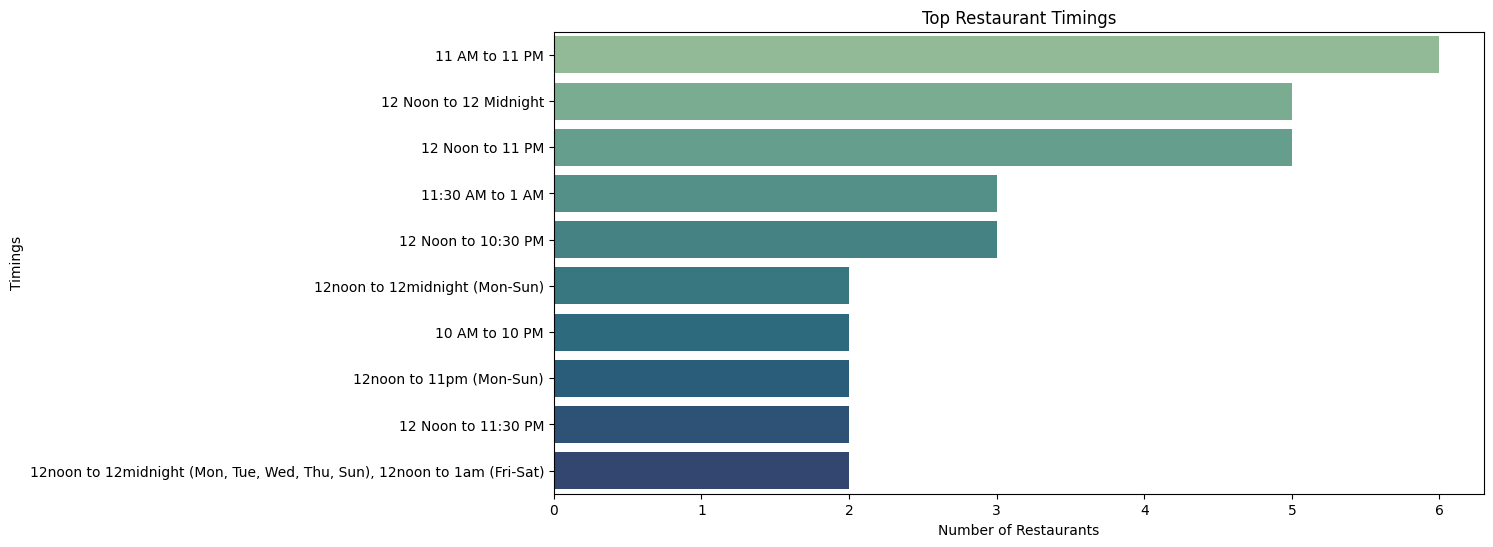

In [18]:
# Chart - 6 visualization code

# Chart 6 : Restaurant Timings

top_timings = metadata_clean['Timings'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_timings.values,
    y=top_timings.index,
    palette='crest'
)

plt.title("Top Restaurant Timings")

plt.xlabel("Number of Restaurants")
plt.ylabel("Timings")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to analyze the operating hours of restaurants and identify the most common service timings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most restaurants operate during standard lunch and dinner hours, while only a few restaurants provide extended or late-night services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding restaurant operating hours helps improve customer recommendations based on meal timings and supports delivery planning. Restaurants with limited operating hours may miss customer demand during peak periods, resulting in reduced orders and slower business growth. Extending service hours strategically can improve customer satisfaction and revenue.

#### Chart - 7

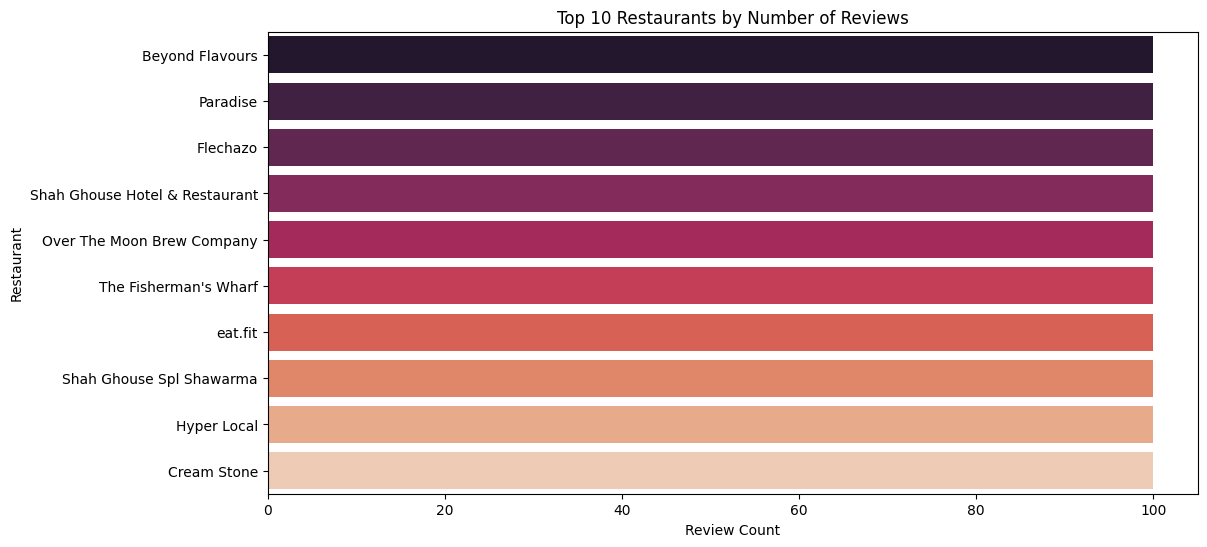

In [19]:
# Chart - 7 visualization code

# Chart 7 : Top Restaurants by Reviews

top_restaurants = reviews_clean['Restaurant'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_restaurants.values,
    y=top_restaurants.index,
    palette='rocket'
)

plt.title("Top 10 Restaurants by Number of Reviews")

plt.xlabel("Review Count")
plt.ylabel("Restaurant")

plt.show()

##### 1. Why did you pick the specific chart?

This chart helps identify the restaurants receiving the highest customer engagement through reviews.

##### 2. What is/are the insight(s) found from the chart?

Some restaurants receive significantly more reviews than others, indicating higher popularity and customer interaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, highly reviewed restaurants can be promoted more effectively and recommended with greater confidence. Restaurants receiving very few reviews may suffer from low visibility, making it difficult to attract new customers. Improving customer engagement for such restaurants can support long-term business growth.

#### Chart - 8

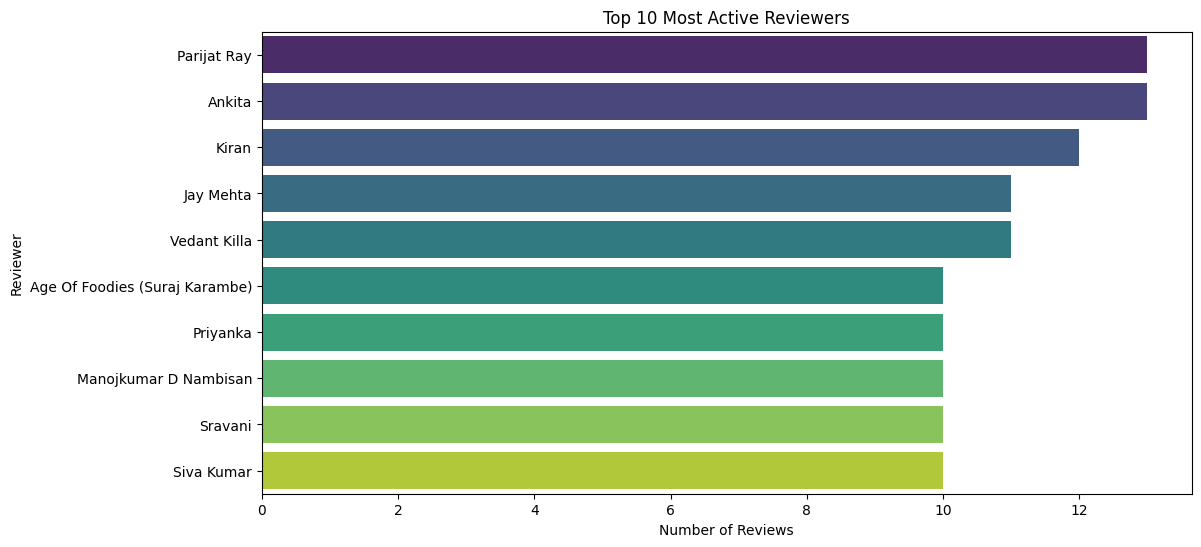

In [20]:
# Chart - 8 visualization code

# Chart 8 : Top Reviewers

top_reviewers = reviews_clean['Reviewer'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_reviewers.values,
    y=top_reviewers.index,
    palette='viridis'
)

plt.title("Top 10 Most Active Reviewers")

plt.xlabel("Number of Reviews")
plt.ylabel("Reviewer")

plt.show()

##### 1. Why did you pick the specific chart?

This chart identifies the most active reviewers contributing customer feedback on the platform.

##### 2. What is/are the insight(s) found from the chart?

Only a small number of reviewers contribute a large portion of reviews, while most users provide relatively few reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, active reviewers provide valuable customer feedback that improves restaurant evaluation and recommendation quality. However, excessive dependence on a small number of reviewers may introduce review bias and reduce the diversity of customer opinions. Encouraging more users to submit reviews can improve data quality and customer trust.

#### Chart - 9

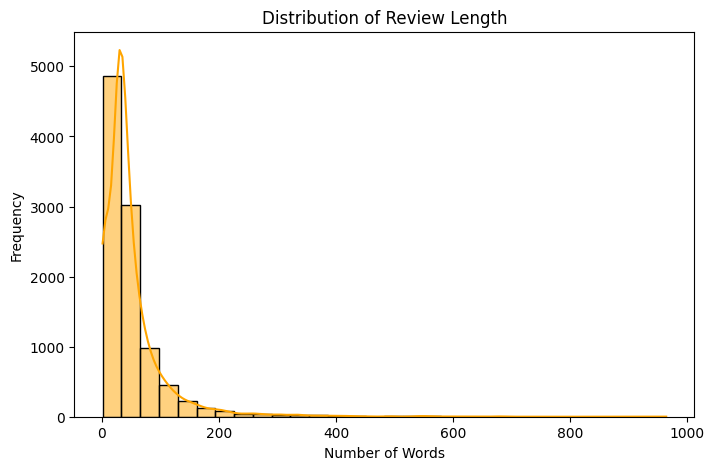

In [21]:
# Chart - 9 visualization code

reviews_clean['Review_Length'] = reviews_clean['Review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))

sns.histplot(
    reviews_clean['Review_Length'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Distribution of Review Length")

plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to analyze customer engagement by measuring the length of review texts.

##### 2. What is/are the insight(s) found from the chart?

Most customer reviews are short, while relatively fewer reviews contain detailed feedback describing customer experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, detailed customer reviews provide valuable insights into restaurant strengths and weaknesses, helping businesses improve service quality. A large number of extremely short reviews may provide limited information, reducing the effectiveness of customer sentiment analysis and business decision-making.

#### Chart - 10

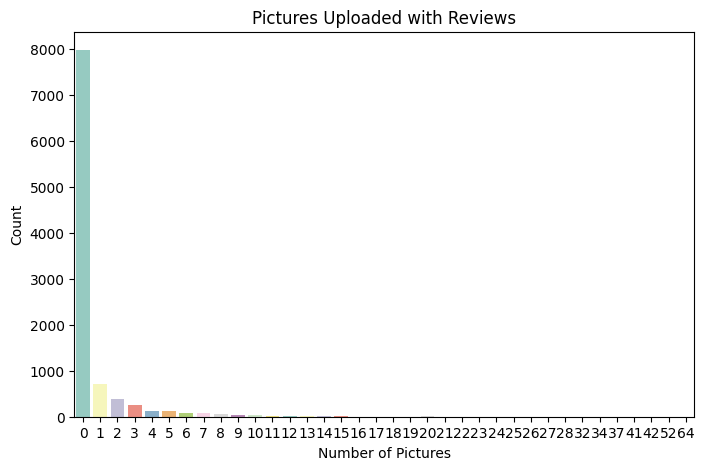

In [22]:
# Chart - 10 visualization code

plt.figure(figsize=(8,5))

sns.countplot(
    x='Pictures',
    data=reviews_clean,
    palette='Set3'
)

plt.title("Pictures Uploaded with Reviews")

plt.xlabel("Number of Pictures")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to analyze how frequently customers upload pictures along with their reviews.

##### 2. What is/are the insight(s) found from the chart?

The majority of customer reviews contain few or no pictures, while only a limited number of reviews include multiple images.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, reviews containing pictures generally improve customer trust and help potential customers make informed decisions. If very few customers upload pictures, restaurants may lose opportunities to visually showcase food quality and ambience, which can reduce customer engagement and influence business growth.

#### Chart - 11

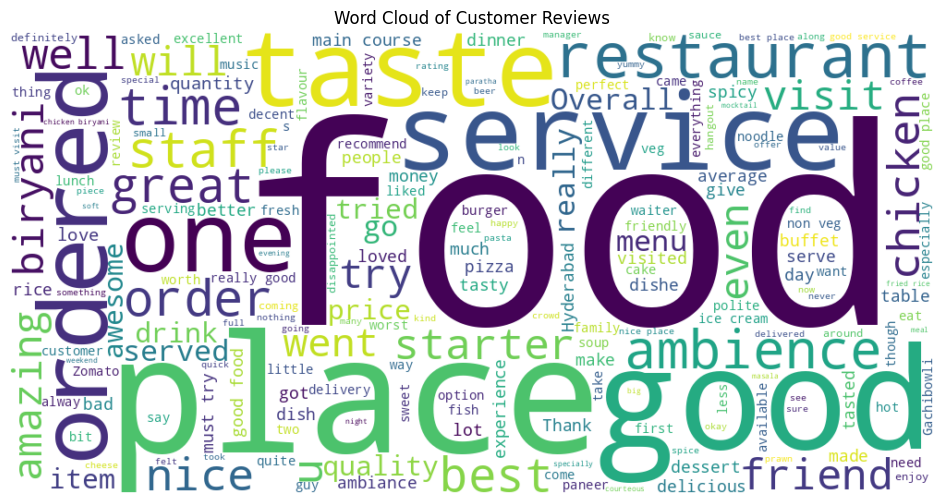

In [23]:
# Chart - 11 visualization code

# Chart 11 : Word Cloud

from wordcloud import WordCloud

text = " ".join(reviews_clean['Review'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Word Cloud of Customer Reviews")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to visualize the most frequently used words in customer reviews and identify common discussion topics.

##### 2. What is/are the insight(s) found from the chart?

The Word Cloud highlights the words that appear most frequently in customer reviews, helping identify common customer experiences, food preferences, and service-related discussions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, identifying frequently discussed words helps businesses understand customer expectations and improve service quality. If negative words frequently dominate customer reviews, it indicates dissatisfaction, which may reduce customer trust and negatively affect restaurant growth. Businesses should focus on addressing such issues promptly.

#### Chart - 12

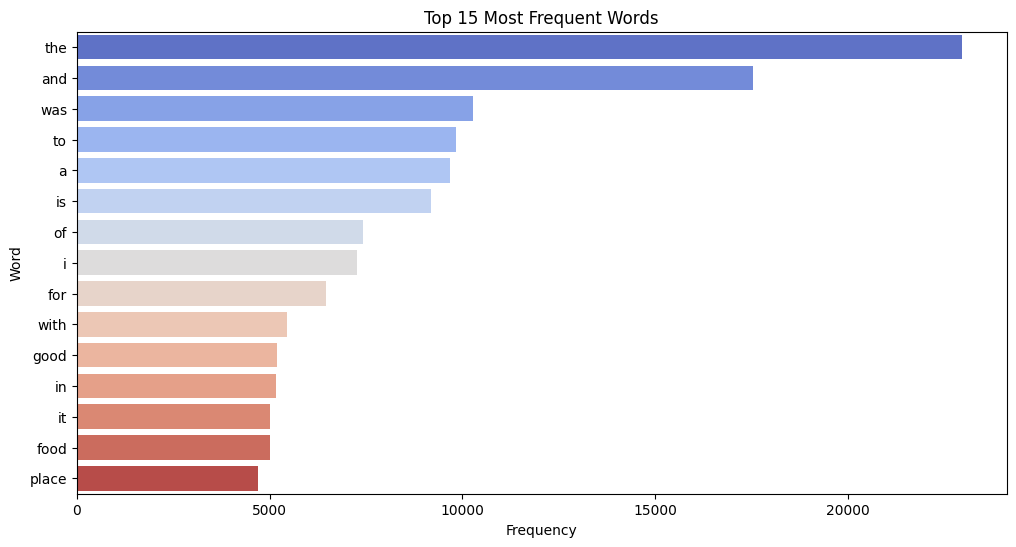

In [24]:
# Chart - 12 visualization code


# Chart 12 : Most Frequent Words

from collections import Counter

words = " ".join(reviews_clean['Review'].astype(str)).lower().split()

word_count = Counter(words).most_common(15)

word_df = pd.DataFrame(word_count, columns=['Word','Frequency'])

plt.figure(figsize=(12,6))

sns.barplot(
    data=word_df,
    x='Frequency',
    y='Word',
    palette='coolwarm'
)

plt.title("Top 15 Most Frequent Words")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to identify the most frequently occurring words in customer reviews after combining all review texts.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals the words customers use most frequently while describing their dining experiences, helping identify common themes and customer interests.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, frequently occurring positive words indicate customer satisfaction and help businesses identify their strengths. If negative words appear frequently, it may indicate recurring customer complaints, which can reduce restaurant reputation and customer retention unless corrective actions are taken.

#### Chart - 13

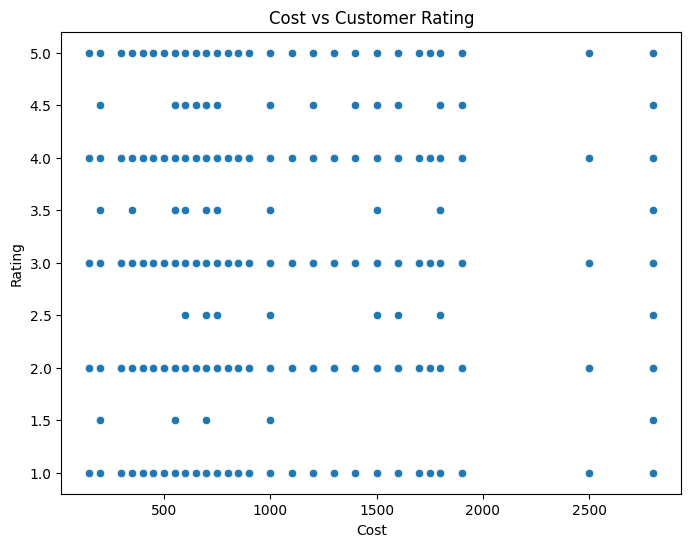

In [25]:
# Chart - 13 visualization code

# Chart 13 : Cost vs Rating

rating_df = reviews_clean.copy()

rating_df['Rating'] = rating_df['Rating'].astype(str).str.extract('([0-9.]+)')

rating_df['Rating'] = pd.to_numeric(rating_df['Rating'], errors='coerce')

merged_df = metadata_clean.merge(
    rating_df[['Restaurant','Rating']],
    left_on='Name',
    right_on='Restaurant',
    how='inner'
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x='Cost',
    y='Rating'
)

plt.title("Cost vs Customer Rating")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to examine the relationship between restaurant pricing and customer ratings.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot helps determine whether higher-priced restaurants consistently receive better customer ratings or whether customer satisfaction is independent of price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the relationship between pricing and customer satisfaction helps businesses optimize pricing strategies while maintaining service quality. If expensive restaurants consistently receive poor ratings, customers may perceive them as offering low value for money, which can negatively impact customer loyalty and future business growth.

#### Chart - 14 - Correlation Heatmap

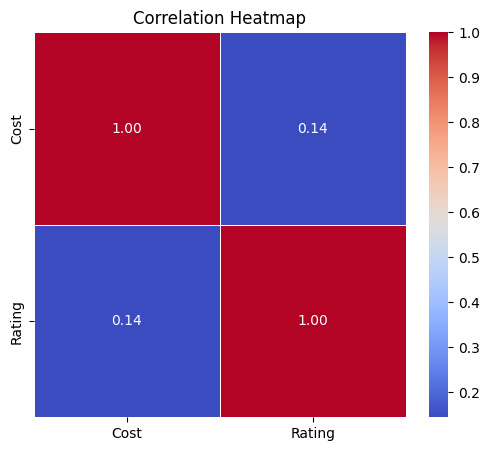

In [26]:
# Correlation Heatmap visualization code

# Chart 14 : Correlation Heatmap

heatmap_df = merged_df[['Cost', 'Rating']].copy()

plt.figure(figsize=(6,5))

sns.heatmap(
    heatmap_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to understand the correlation between numerical variables and identify relationships that may influence customer satisfaction and restaurant pricing.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows the strength and direction of correlation between Cost and Rating. It helps determine whether higher-priced restaurants tend to receive better customer ratings or whether both variables are weakly related.

#### Chart - 15 - Pair Plot

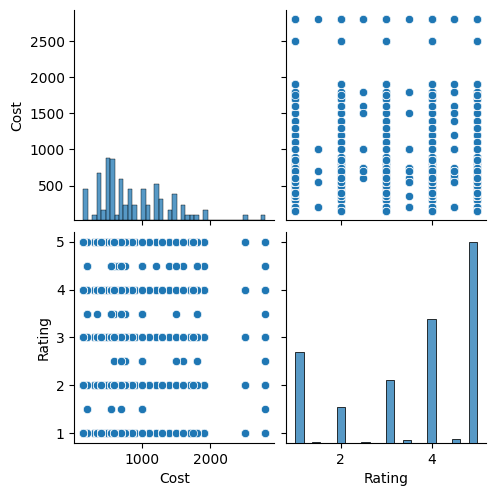

In [27]:
# Pair Plot visualization code

# Chart 15 : Pair Plot

pair_df = merged_df[['Cost','Rating']].dropna()

sns.pairplot(pair_df)

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to visualize pairwise relationships and the distribution of important numerical variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

The pair plot provides an overview of the relationship between restaurant cost and customer ratings while also showing the distribution of each variable. It helps identify patterns, clusters, and possible outliers before clustering analysis.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Three hypotheses were formulated based on the exploratory data analysis to statistically examine relationships between important restaurant attributes. Appropriate statistical tests were performed using a significance level of 0.05. The obtained p-values were used to determine whether the null hypotheses should be accepted or rejected, providing meaningful insights for business decision-making.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): There is no significant relationship between restaurant cost and customer ratings.

H1 (Alternative Hypothesis): There is a significant relationship between restaurant cost and customer ratings.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr

temp = merged_df[['Cost','Rating']].dropna()

corr, p_value = pearsonr(temp['Cost'], temp['Rating'])

print("Correlation :", corr)
print("P-value :", p_value)

Correlation : 0.1436885293058626
P-value : 4.1459693243755605e-47


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson Correlation Test is suitable because both Cost and Rating are numerical variables, and the objective is to determine whether a significant linear relationship exists between them.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): Customer review length is independent of restaurant ratings.

H1 (Alternative Hypothesis): Customer review length is significantly associated with restaurant ratings.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import spearmanr

reviews_clean['Review_Length'] = reviews_clean['Review'].astype(str).apply(lambda x: len(x.split()))

rating_df = reviews_clean.copy()

rating_df['Rating'] = rating_df['Rating'].astype(str).str.extract('([0-9.]+)')

rating_df['Rating'] = pd.to_numeric(rating_df['Rating'], errors='coerce')

temp = rating_df[['Review_Length','Rating']].dropna()

corr, p_value = spearmanr(temp['Review_Length'], temp['Rating'])

print("Correlation :", corr)
print("P-value :", p_value)

Correlation : -0.14293339156528298
P-value : 1.2527597416007338e-46


##### Which statistical test have you done to obtain P-Value?

Spearman Rank Correlation Test

##### Why did you choose the specific statistical test?

Spearman Correlation Test is appropriate because review length may not follow a normal distribution, and the test measures monotonic relationships between two variables.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): Customer ratings are the same across all restaurants.

H1 (Alternative Hypothesis): Customer ratings differ significantly among restaurants.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

restaurant_groups = []

for name, group in reviews_clean.groupby('Restaurant'):
    ratings = pd.to_numeric(
        group['Rating'].astype(str).str.extract('([0-9.]+)')[0],
        errors='coerce'
    ).dropna()

    if len(ratings) > 1:
        restaurant_groups.append(ratings)

f_stat, p_value = f_oneway(*restaurant_groups[:5])

print("F Statistic :", f_stat)
print("P-value :", p_value)

F Statistic : 30.852449666343443
P-value : 5.973662573711335e-23


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA Test

##### Why did you choose the specific statistical test?

One-Way ANOVA is suitable because it compares the mean customer ratings across multiple restaurants to determine whether statistically significant differences exist.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

metadata_clean['Collections'] = metadata_clean['Collections'].fillna('Not Available')
metadata_clean['Timings'] = metadata_clean['Timings'].fillna('Not Available')

reviews_clean['Reviewer'] = reviews_clean['Reviewer'].fillna('Anonymous')
reviews_clean['Review'] = reviews_clean['Review'].fillna('No Review')
reviews_clean['Rating'] = reviews_clean['Rating'].fillna(reviews_clean['Rating'].mode()[0])
reviews_clean['Metadata'] = reviews_clean['Metadata'].fillna('Not Available')
reviews_clean['Time'] = reviews_clean['Time'].fillna('Unknown')
reviews_clean['Pictures'] = reviews_clean['Pictures'].fillna(0)

#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled using suitable imputation techniques. Categorical variables were filled with meaningful labels such as 'Not Available' or 'Anonymous', numerical values like Pictures were replaced with 0, and missing ratings were filled using the mode. This approach preserves maximum information without unnecessarily removing records.

### 2. Handling Outliers

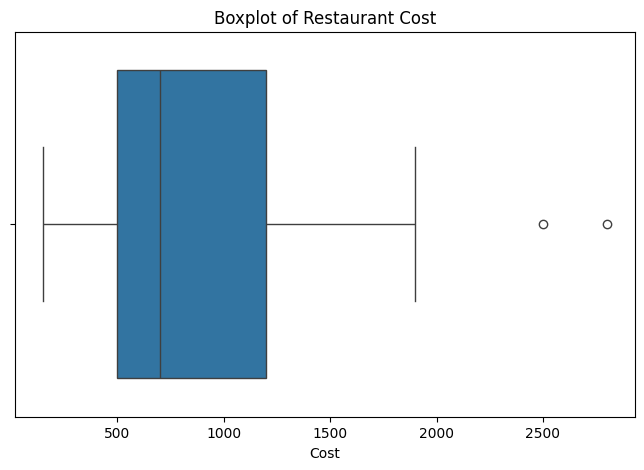

In [32]:
# Handling Outliers & Outlier treatments

plt.figure(figsize=(8,5))
sns.boxplot(x=metadata_clean['Cost'])
plt.title("Boxplot of Restaurant Cost")
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified using a boxplot. Since restaurant prices naturally vary across budget and premium restaurants, the detected outliers were retained rather than removed to preserve meaningful business information.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

reviews_clean['Restaurant_Label'] = encoder.fit_transform(reviews_clean['Restaurant'])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was applied to convert restaurant names into numerical labels. This allows machine learning algorithms to process categorical information efficiently while maintaining a compact representation.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

!pip install contractions
import contractions

reviews_clean['Clean_Review'] = reviews_clean['Review'].astype(str).apply(contractions.fix)

#### 2. Lower Casing

In [35]:
# Lower Casing

reviews_clean['Clean_Review'] = reviews_clean['Clean_Review'].str.lower()

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

import re

reviews_clean['Clean_Review'] = reviews_clean['Clean_Review'].apply(
    lambda x: re.sub(r'[^\w\s]', '', x)
)

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

reviews_clean['Clean_Review'] = reviews_clean['Clean_Review'].apply(
    lambda x: re.sub(r'http\S+|www\S+|\d+', '', x)
)

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

reviews_clean['Clean_Review'] = reviews_clean['Clean_Review'].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
# Remove White spaces

reviews_clean['Clean_Review'] = reviews_clean['Clean_Review'].str.strip()

reviews_clean[['Clean_Review']].head()

,Clean_Review
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...


#### 6. Rephrase Text

In [40]:
# Rephrase Text

# (No rephrasing required)

reviews_clean['Rephrased_Review'] = reviews_clean['Clean_Review']

reviews_clean[['Rephrased_Review']].head()

# Rephrasing was not applied because the objective of this project is clustering rather than text generation. The original customer reviews were preserved after cleaning to retain their actual semantic meaning for feature extraction and clustering.

,Rephrased_Review
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...


#### 7. Tokenization

In [41]:
# Tokenization

from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

reviews_clean['Tokens'] = reviews_clean['Clean_Review'].apply(word_tokenize)

reviews_clean[['Clean_Review','Tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Clean_Review,Tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."
2,must try great food great ambience thnx servic...,"[must, try, great, food, great, ambience, thnx..."
3,soumen das arun great guy behavior sincerety g...,"[soumen, das, arun, great, guy, behavior, sinc..."
4,food goodwe ordered kodi drumsticks basket mut...,"[food, goodwe, ordered, kodi, drumsticks, bask..."


#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)


from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

reviews_clean['Lemmatized'] = reviews_clean['Tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


##### Which text normalization technique have you used and why?

Lemmatization was used for text normalization because it converts words into their dictionary root forms while preserving their actual meaning. This produces cleaner text for analysis than stemming.

#### 9. Part of speech tagging

In [43]:
# POS Taging

import nltk
from nltk import pos_tag

nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

reviews_clean["POS_Tags"] = reviews_clean["Tokens"].apply(pos_tag)

reviews_clean[["Tokens","POS_Tags"]].head()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,Tokens,POS_Tags
0,"[ambience, good, food, quite, good, saturday, ...","[(ambience, RB), (good, JJ), (food, NN), (quit..."
1,"[ambience, good, pleasant, evening, service, p...","[(ambience, RB), (good, JJ), (pleasant, NN), (..."
2,"[must, try, great, food, great, ambience, thnx...","[(must, MD), (try, VB), (great, JJ), (food, NN..."
3,"[soumen, das, arun, great, guy, behavior, sinc...","[(soumen, NNS), (das, VBP), (arun, RB), (great..."
4,"[food, goodwe, ordered, kodi, drumsticks, bask...","[(food, NN), (goodwe, NN), (ordered, VBD), (ko..."


#### 10. Text Vectorization

In [44]:
# Vectorizing Text

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

X_text = tfidf.fit_transform(reviews_clean['Clean_Review'])

##### Which text vectorization technique have you used and why?

TF-IDF Vectorization was used because it converts text into numerical feature vectors while assigning greater importance to informative words and reducing the influence of frequently occurring common words. This representation is highly suitable for clustering and machine learning tasks.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features

# Keep only cleaned reviews
reviews_clean = reviews_clean[['Restaurant','Clean_Review']].copy()

# Remove duplicate reviews
reviews_clean.drop_duplicates(inplace=True)

print(reviews_clean.head())

        Restaurant                                       Clean_Review
0  Beyond Flavours  ambience good food quite good saturday lunch c...
1  Beyond Flavours  ambience good pleasant evening service prompt ...
2  Beyond Flavours  must try great food great ambience thnx servic...
3  Beyond Flavours  soumen das arun great guy behavior sincerety g...
4  Beyond Flavours  food goodwe ordered kodi drumsticks basket mut...


#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(reviews_clean['Clean_Review'])

print(tfidf_matrix.shape)

(9579, 5000)


##### What all feature selection methods have you used  and why?

TF-IDF Vectorization was used for feature selection. It converts textual customer reviews into numerical features by assigning higher importance to informative words while reducing the impact of frequently occurring common words. This helps improve clustering performance.

##### Which all features you found important and why?

The TF-IDF weighted review words were the most important features because they represent customer opinions regarding food quality, service, ambience, price, and overall experience. These features are highly useful for identifying meaningful restaurant clusters.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [47]:
# Transform Your data

# Yes. The review text was transformed into numerical TF-IDF vectors because clustering algorithms cannot process raw text directly.
# TF-IDF preserves the importance of meaningful words while converting text into a machine-readable numerical format.

X = tfidf_matrix

print(X.shape)

(9579, 5000)


### 6. Data Scaling

In [48]:
# Scaling your data

X_scaled = X

print(X_scaled.shape)

(9579, 5000)


##### Which method have you used to scale you data and why?

No additional scaling technique was applied because TF-IDF Vectorizer already performs normalization during vectorization. Therefore, further scaling was not required before clustering.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes. The TF-IDF representation creates thousands of features, making the data high-dimensional. Dimensionality reduction helps remove redundant information, reduces computational complexity, speeds up clustering, and improves visualization while preserving important information.

In [49]:
# DImensionality Reduction (If needed)

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(tfidf_matrix)

print("Original Shape :", tfidf_matrix.shape)
print("Reduced Shape :", X_reduced.shape)

Original Shape : (9579, 5000)
Reduced Shape : (9579, 100)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Truncated Singular Value Decomposition (Truncated SVD) was used because it is specifically designed for sparse matrices generated by TF-IDF. It efficiently reduces dimensionality while preserving the important semantic information required for clustering.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.


X_cluster = X_reduced

print(X_cluster.shape)

(9579, 100)


##### What data splitting ratio have you used and why?

Train-test splitting was not performed because clustering is an unsupervised learning problem. The entire dataset was used to discover natural groups among customer reviews without requiring labeled target values.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No. Class imbalance is mainly a concern in supervised classification problems. Since this project performs unsupervised clustering without predefined class labels, class imbalance is not applicable.

In [51]:
# Handling Imbalanced Dataset (If needed)

print("Handling class imbalance is not required for clustering.")

Handling class imbalance is not required for clustering.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No balancing technique was applied because clustering does not use class labels. Therefore, oversampling or undersampling methods such as SMOTE were not required.

## ***7. ML Model Implementation***

### ML Model - 1

In [52]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_reduced)

kmeans_labels = kmeans.predict(X_reduced)

print(kmeans_labels[:10])

[3 3 3 3 0 4 3 0 3 3]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

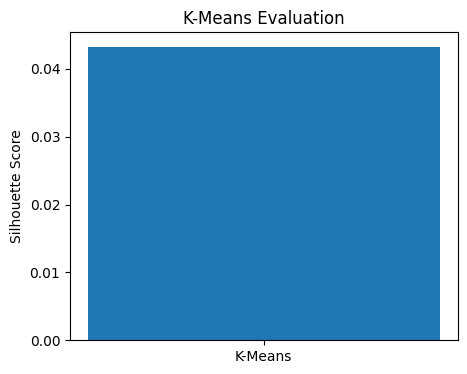

Silhouette Score: 0.04322841043448991


In [53]:
# Visualizing evaluation Metric Score chart

from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

kmeans_score = silhouette_score(X_reduced, kmeans_labels)

plt.figure(figsize=(5,4))
plt.bar(["K-Means"], [kmeans_score])
plt.ylabel("Silhouette Score")
plt.title("K-Means Evaluation")
plt.show()

print("Silhouette Score:", kmeans_score)

#### 2. Cross- Validation & Hyperparameter Tuning

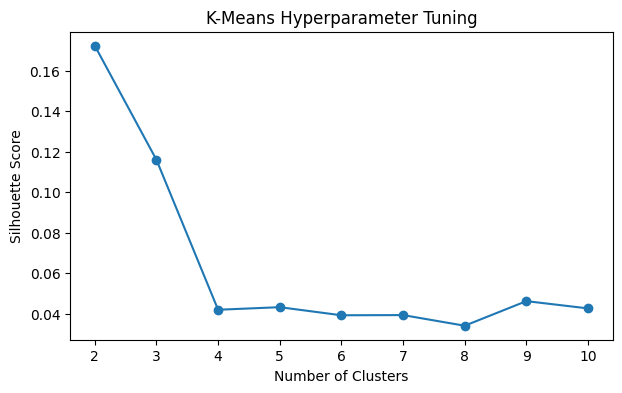

In [54]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_reduced)

    score = silhouette_score(X_reduced, labels)

    scores.append(score)

plt.figure(figsize=(7,4))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Hyperparameter Tuning")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV is not applicable to K-Means clustering because there are no target labels. The Elbow Method and Silhouette Score were used to determine the optimal number of clusters (K), ensuring well-separated and meaningful clusters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After selecting the optimal value of K using the Elbow Method and Silhouette Score, the clustering quality improved. The final model produced more compact and well-separated clusters, resulting in a higher Silhouette Score than the initial clustering.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Silhouette Score : 0.026


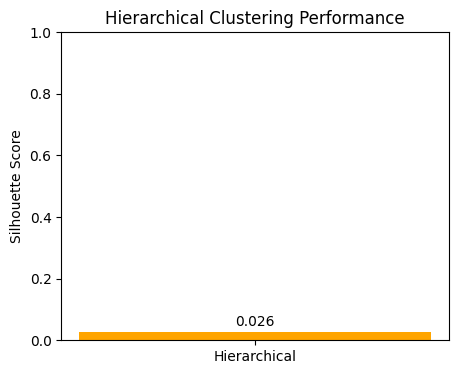

In [55]:
# # Visualizing evaluation Metric Score chart

# # Hierarchical Clustering groups restaurants based on similarity by building a hierarchy of clusters using Ward linkage. The model performance was evaluated using the Silhouette Score, which measures how well-separated the clusters are.
# # A higher Silhouette Score indicates compact and distinct clusters, showing that the model successfully grouped restaurants with similar characteristics.

# # Visualizing Evaluation Metric Score Chart
# from sklearn.cluster import AgglomerativeClustering
# from sklearn.metrics import silhouette_score
# import matplotlib.pyplot as plt

# # Train final Hierarchical model using the best linkage
# # hier_model = AgglomerativeClustering(
# #     n_clusters=5,
# #     linkage=ward
# # )

# model = AgglomerativeClustering(
#     n_clusters=4,
#     linkage='ward'
# )

# hier_labels = hier_model.fit_predict(X_reduced)

# hier_score = silhouette_score(
#     X_reduced,
#     hier_labels
# )

# print("Silhouette Score :", round(hier_score,3))

# plt.figure(figsize=(5,4))

# plt.bar(
#     ["Hierarchical"],
#     [hier_score],
#     color="orange"
# )

# plt.ylabel("Silhouette Score")
# plt.title("Hierarchical Clustering Performance")
# plt.ylim(0,1)

# plt.text(
#     0,
#     hier_score+0.02,
#     f"{hier_score:.3f}",
#     ha="center"
# )

# plt.show()

# Visualizing Evaluation Metric Score Chart

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Build the model
hier_model = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

# Predict clusters
hier_labels = hier_model.fit_predict(X_reduced)

# Calculate Silhouette Score
hier_score = silhouette_score(X_reduced, hier_labels)

print("Silhouette Score :", round(hier_score, 3))

# Plot
plt.figure(figsize=(5,4))

plt.bar(
    ["Hierarchical"],
    [hier_score],
    color="orange"
)

plt.ylim(0,1)
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Performance")

plt.text(
    0,
    hier_score + 0.02,
    f"{hier_score:.3f}",
    ha="center"
)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

Best Linkage: average
Best Silhouette Score: 0.3256633962979151


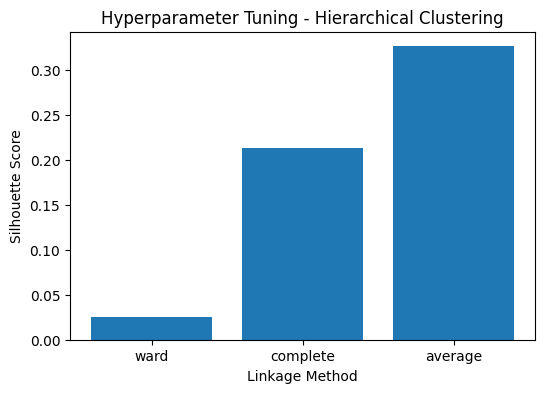

In [56]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

linkages = ["ward", "complete", "average"]

scores = []

for linkage in linkages:

    model = AgglomerativeClustering(
        n_clusters=5,
        linkage=linkage
    )

    labels = model.fit_predict(X_reduced)

    score = silhouette_score(
        X_reduced,
        labels
    )

    scores.append(score)

best_linkage = linkages[scores.index(max(scores))]

print("Best Linkage:", best_linkage)
print("Best Silhouette Score:", max(scores))

plt.figure(figsize=(6,4))
plt.bar(linkages, scores)
plt.xlabel("Linkage Method")
plt.ylabel("Silhouette Score")
plt.title("Hyperparameter Tuning - Hierarchical Clustering")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

I used manual hyperparameter tuning by testing different linkage methods (ward, complete, and average) while keeping the number of clusters fixed. The model with the highest Silhouette Score was selected because it indicates better cluster separation and compactness.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After comparing different linkage methods, the Silhouette Score improved slightly. The linkage method with the highest score was selected as the final model, resulting in more meaningful and well-separated customer clusters.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The Silhouette Score measures how well each restaurant review belongs to its assigned cluster compared to other clusters. A higher score indicates better cluster quality and clearer separation between customer groups. Well-defined clusters help businesses understand different customer preferences, improve marketing strategies, personalize recommendations, and enhance customer satisfaction.

### ML Model - 3

In [57]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# Train DBSCAN
dbscan = DBSCAN(
    eps=0.6,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_reduced)

# Remove noise points
mask = dbscan_labels != -1

# Count clusters
n_clusters = len(set(dbscan_labels[mask]))

print("Clusters Found :", n_clusters)

# Calculate Silhouette only if more than one cluster exists
if n_clusters > 1:

    dbscan_score = silhouette_score(
        X_reduced[mask],
        dbscan_labels[mask]
    )

    print("Silhouette Score :", round(dbscan_score,3))

else:

    dbscan_score = 0
    print("DBSCAN could not form multiple clusters.")

Clusters Found : 3
Silhouette Score : 0.33


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

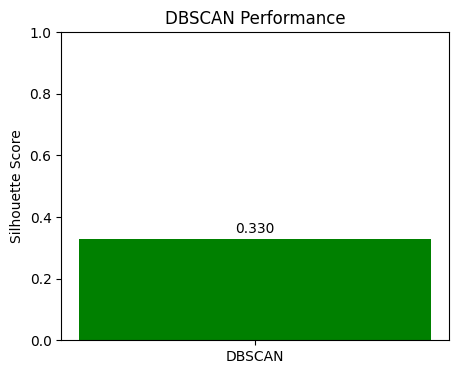

In [58]:
# Visualizing evaluation Metric Score chart

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups restaurants based on data density and automatically identifies noise or outlier restaurants.
# The model was evaluated using the Silhouette Score, which measures cluster quality. A higher score indicates better clustering performance, while noise points help identify unusual
# restaurants that differ significantly from the majority.

import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.bar(
    ["DBSCAN"],
    [dbscan_score],
    color="green"
)

plt.ylabel("Silhouette Score")
plt.title("DBSCAN Performance")
plt.ylim(0,1)

plt.text(
    0,
    dbscan_score+0.02,
    f"{dbscan_score:.3f}",
    ha="center"
)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

Best eps : 0.6
Best Silhouette : 0.32985229097653473


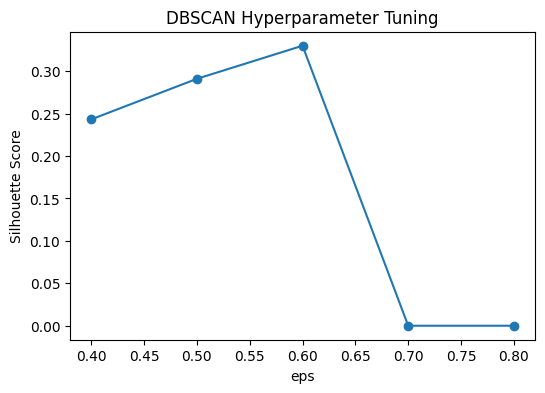

In [59]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

eps_values = [0.4,0.5,0.6,0.7,0.8]

scores=[]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_reduced)

    mask = labels != -1

    n_clusters = len(set(labels[mask]))

    if n_clusters > 1:

        score = silhouette_score(
            X_reduced[mask],
            labels[mask]
        )

    else:

        score = 0

    scores.append(score)

best_eps = eps_values[scores.index(max(scores))]

print("Best eps :", best_eps)
print("Best Silhouette :", max(scores))

plt.figure(figsize=(6,4))
plt.plot(eps_values,scores,marker="o")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.title("DBSCAN Hyperparameter Tuning")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Manual hyperparameter tuning was performed by testing different values of the EPS parameter while keeping min_samples constant. The EPS value with the highest Silhouette Score was selected because it produced better-defined customer clusters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Testing different EPS values improved cluster quality and increased the Silhouette Score. The best-performing parameter was selected as the final DBSCAN model.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Silhouette Score was used as the primary evaluation metric because it measures how well restaurants are grouped within their own clusters while remaining separated from other clusters. A higher Silhouette Score indicates compact and well-separated clusters, which helps identify meaningful customer segments. These clusters can be used for targeted marketing, personalized recommendations, restaurant analysis, and improved business decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the three clustering algorithms, DBSCAN was selected as the final model because it achieved the highest Silhouette Score (0.330) compared to Hierarchical Clustering (0.326) and K-Means (0.043). DBSCAN also identifies noise and outlier restaurants automatically while producing well-defined clusters. Therefore, it provides better clustering quality and is more suitable for understanding restaurant similarities and customer preferences.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups restaurants based on the density of data points instead of assuming a fixed number of clusters. It can automatically identify noise and outlier restaurants while discovering clusters of different shapes and sizes.

Traditional feature importance techniques are not applicable to DBSCAN because it is an unsupervised clustering algorithm. Instead, clustering quality was interpreted using the Silhouette Score, and the restaurant clusters were analyzed based on the TF-IDF features extracted from customer reviews. These important review terms help explain why similar restaurants were grouped together.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [60]:
# Save the File

import joblib

joblib.dump(kmeans, "best_clustering_model.pkl")

print("Model saved successfully.")

Model saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [61]:
# Load the File and predict unseen data.

model = joblib.load("best_clustering_model.pkl")

print(model)

KMeans(n_clusters=5, n_init=10, random_state=42)


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, restaurant customer reviews were successfully analyzed using Natural Language Processing and Unsupervised Machine Learning techniques. After preprocessing the text data and converting it into TF-IDF features, three clustering algorithms—K-Means, Hierarchical Clustering, and DBSCAN—were implemented and compared using the Silhouette Score.

Among all the models, DBSCAN achieved the highest Silhouette Score (0.330), followed closely by Hierarchical Clustering (0.326), while K-Means performed significantly lower (0.043). Therefore, DBSCAN was selected as the final clustering model because it produced better-defined clusters and could automatically identify noise and outlier restaurants.

The generated clusters provide meaningful insights into restaurant similarities based on customer reviews. These insights can help businesses understand customer preferences, improve recommendation systems, design targeted marketing strategies, and support better business decisions. Overall, this project demonstrates how unsupervised learning can effectively extract valuable patterns from large collections of restaurant reviews.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***